In [1]:
import numpy as np
from AttitudeAviary2 import *
from stable_baselines3 import PPO

In [2]:
env = AttitudeAviary2_2()

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


c:\Users\awals\AppData\Local\Programs\Python\Python39\lib\site-packages\gym\logger.py:34: UserWarning: WARN: Box bound precision lowered by casting to float32
  warnings.warn(colorize("%s: %s" % ("WARN", msg % args), "yellow"))


In [3]:
import os
from stable_baselines3.common.monitor import Monitor

log_dir = "C:/Users/awals/OneDrive/Documents/Academic/DDP/Implementations/attitude_sb3_logs"
os.makedirs(log_dir, exist_ok=True)
env = Monitor(env, log_dir)

In [4]:
from stable_baselines3.common.callbacks import EvalCallback
eval_env = AttitudeAviary2_2()
eval_env = Monitor(eval_env)

eval_callback = EvalCallback(eval_env,
            log_path="C:/Users/awals/OneDrive/Documents/Academic/DDP/Implementations/attitude_sb3_logs",
            n_eval_episodes=2,
            eval_freq=1000,
            deterministic=True) 

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


In [5]:
model = PPO('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=500000, callback=eval_callback)

Using cuda device
Wrapping the env in a DummyVecEnv.
Eval num_timesteps=1000, episode_reward=-42.25 +/- 24.53
Episode length: 241.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 241      |
|    mean_reward     | -42.3    |
| time/              |          |
|    total_timesteps | 1000     |
---------------------------------
New best mean reward!
Eval num_timesteps=2000, episode_reward=-8.68 +/- 1.16
Episode length: 241.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 241      |
|    mean_reward     | -8.68    |
| time/              |          |
|    total_timesteps | 2000     |
---------------------------------
New best mean reward!
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 241      |
|    ep_rew_mean     | -150     |
| time/              |          |
|    fps             | 279      |
|    iterations      | 1        |
|    time_ela

In [6]:
model.save("attitude_sb3_logs/PPO_Attitude2")

In [7]:
history = np.load("attitude_sb3_logs/evaluations.npz")
rewards = np.average(history["results"], axis=1)
print(rewards.shape)

(501,)


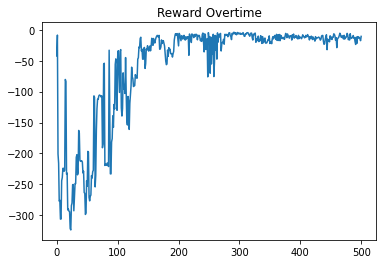

In [8]:
import matplotlib.pyplot as plt

plt.plot(rewards)
plt.title("Reward Overtime")
plt.show()

In [9]:
rpy_errs = []
cumm_reward = 0
obs = env.reset()
for i in range(1*env.SIM_FREQ):
    action, _states = model.predict(obs)
    obs, reward, done, info = env.step(action)
    cumm_reward += reward
    rpy_errs.append(info['rpy_err'])

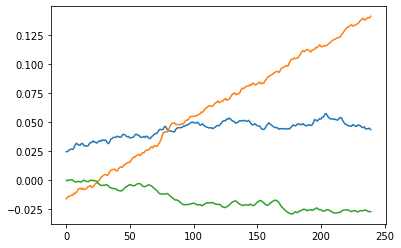

In [10]:
plt.plot(rpy_errs)

In [12]:
model.learn(total_timesteps=240000, callback=eval_callback)

Eval num_timesteps=240, episode_reward=-14.53 +/- 0.82
Episode length: 241.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 241      |
|    mean_reward     | -14.5    |
| time/              |          |
|    total_timesteps | 240      |
---------------------------------
Eval num_timesteps=1240, episode_reward=-17.07 +/- 3.38
Episode length: 241.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 241      |
|    mean_reward     | -17.1    |
| time/              |          |
|    total_timesteps | 1240     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 241      |
|    ep_rew_mean     | -10.5    |
| time/              |          |
|    fps             | 385      |
|    iterations      | 1        |
|    time_elapsed    | 5        |
|    total_timesteps | 2048     |
---------------------------------
Eval num_

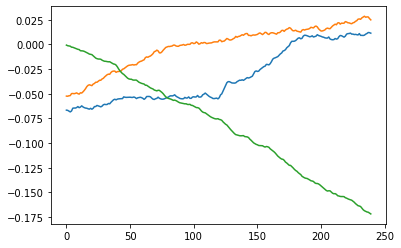

In [13]:
rpy_errs = []
cumm_reward = 0
obs = env.reset()
for i in range(1*env.SIM_FREQ):
    action, _states = model.predict(obs)
    obs, reward, done, info = env.step(action)
    cumm_reward += reward
    rpy_errs.append(info['rpy_err'])

plt.plot(rpy_errs)
plt.show()